In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cardio_train.csv', sep=';')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [2]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
al

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
df['age'] = (df['age'] / 365.25).astype(int)

df = df[
    (df['height'] >= 100) & (df['height'] <= 250) &
    (df['weight'] >= 30) & (df['weight'] <= 200) &
    (df['ap_hi'] >= 80) & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) & (df['ap_lo'] <= 150) &
    (df['ap_hi'] >= df['ap_lo'])
]

df = df.drop('id', axis=1)

print("Dataset after cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset after cleaning:
Rows: 68632
Columns: 12


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


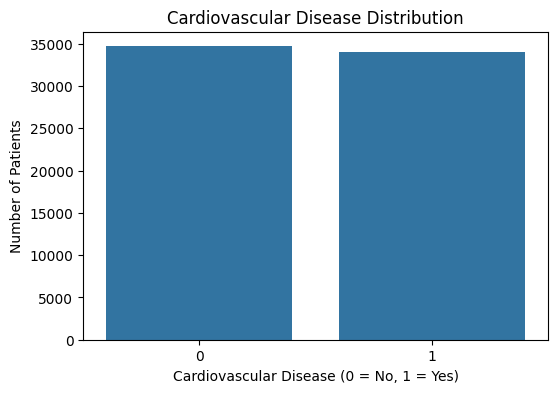

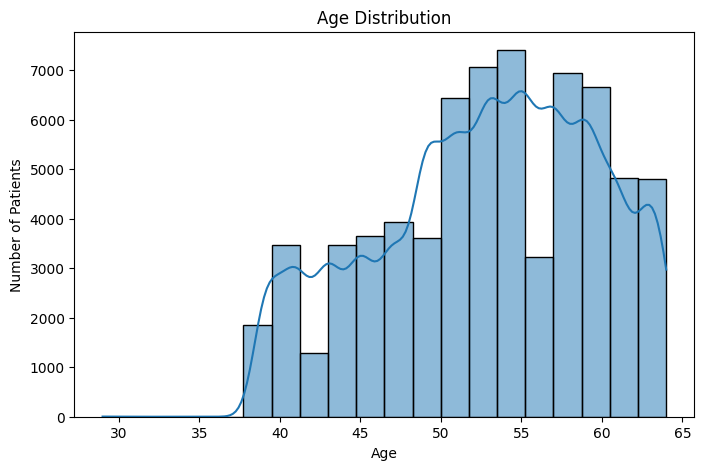

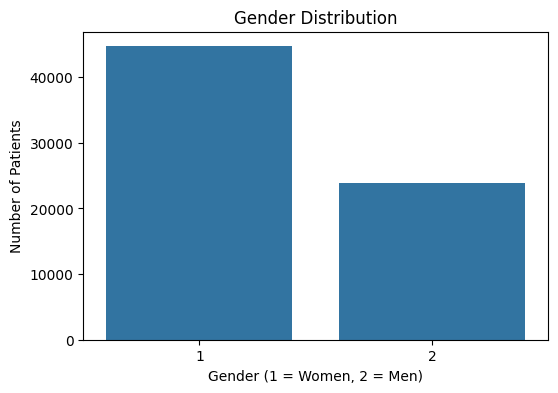

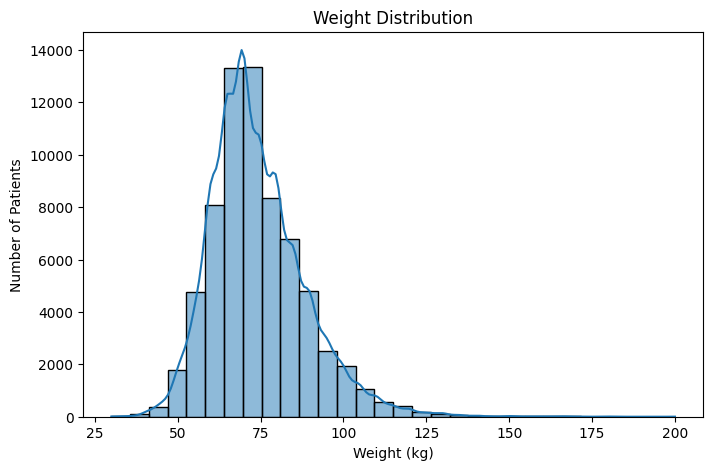

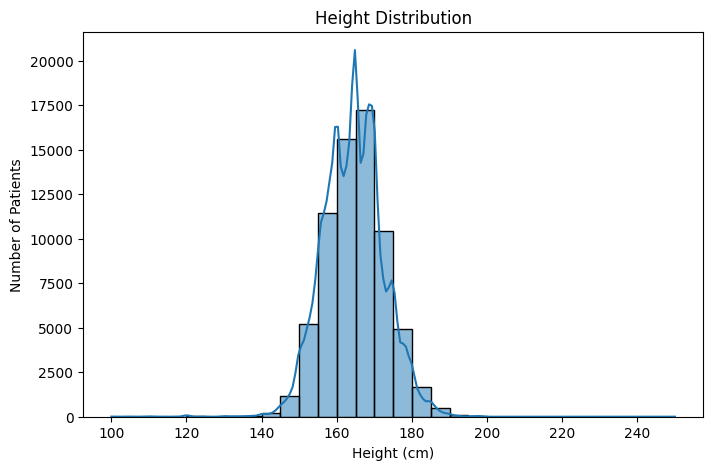

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df)
plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardiovascular Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender (1 = Women, 2 = Men)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['weight'], bins=30, kde=True)
plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df['height'], bins=30, kde=True)
plt.title('Height Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Number of Patients')
plt.show()

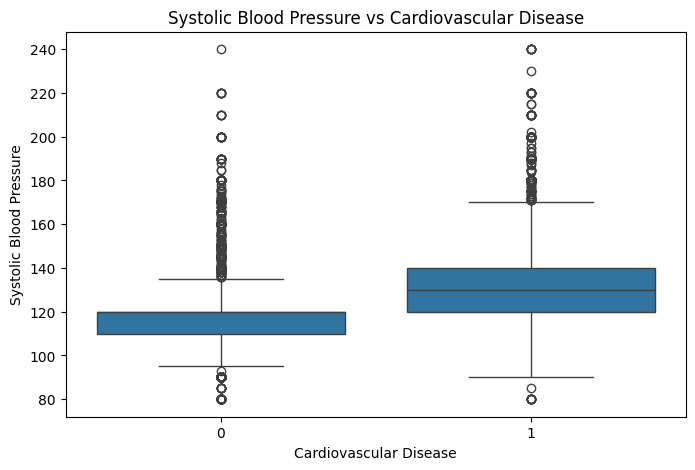

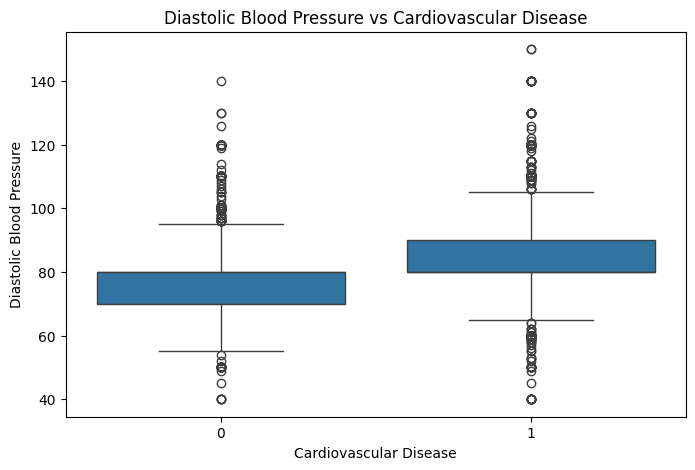

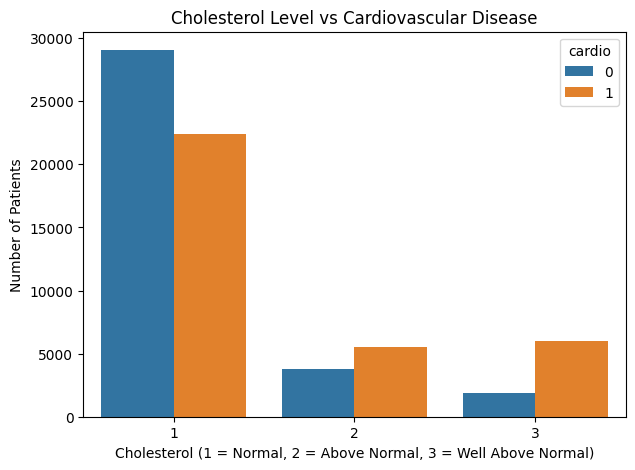

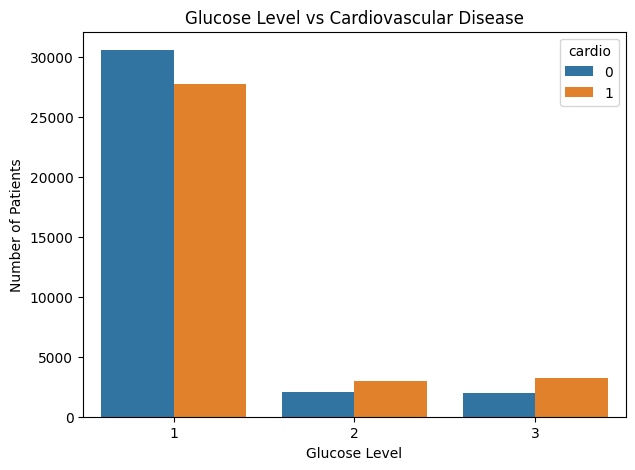

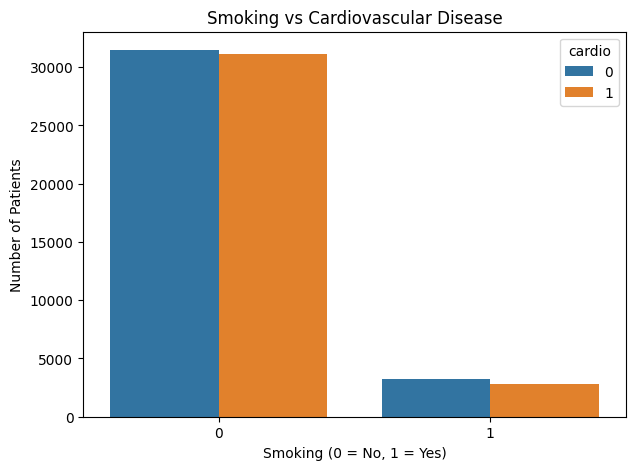

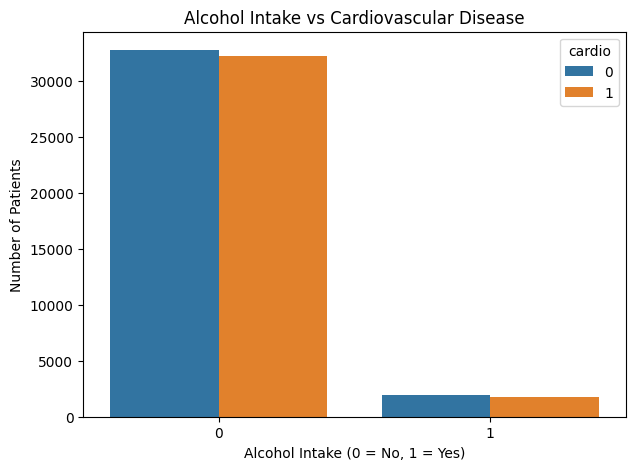

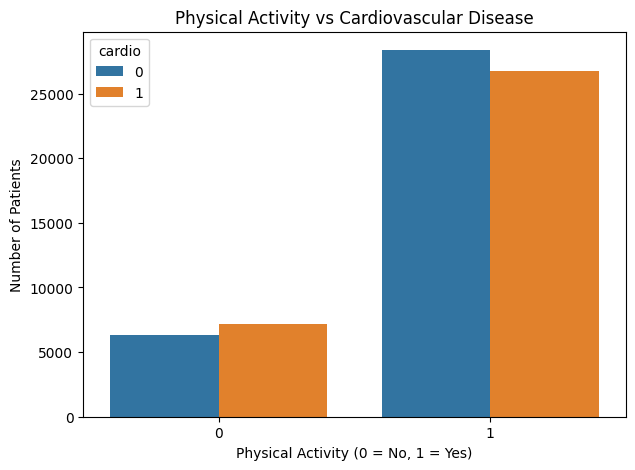

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.title('Systolic Blood Pressure vs Cardiovascular Disease')
plt.xlabel('Cardiovascular Disease')
plt.ylabel('Systolic Blood Pressure')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='cardio', y='ap_lo', data=df)
plt.title('Diastolic Blood Pressure vs Cardiovascular Disease')
plt.xlabel('Cardiovascular Disease')
plt.ylabel('Diastolic Blood Pressure')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol Level vs Cardiovascular Disease')
plt.xlabel('Cholesterol (1 = Normal, 2 = Above Normal, 3 = Well Above Normal)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='gluc', hue='cardio', data=df)
plt.title('Glucose Level vs Cardiovascular Disease')
plt.xlabel('Glucose Level')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='smoke', hue='cardio', data=df)
plt.title('Smoking vs Cardiovascular Disease')
plt.xlabel('Smoking (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='alco', hue='cardio', data=df)
plt.title('Alcohol Intake vs Cardiovascular Disease')
plt.xlabel('Alcohol Intake (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='active', hue='cardio', data=df)
plt.title('Physical Activity vs Cardiovascular Disease')
plt.xlabel('Physical Activity (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

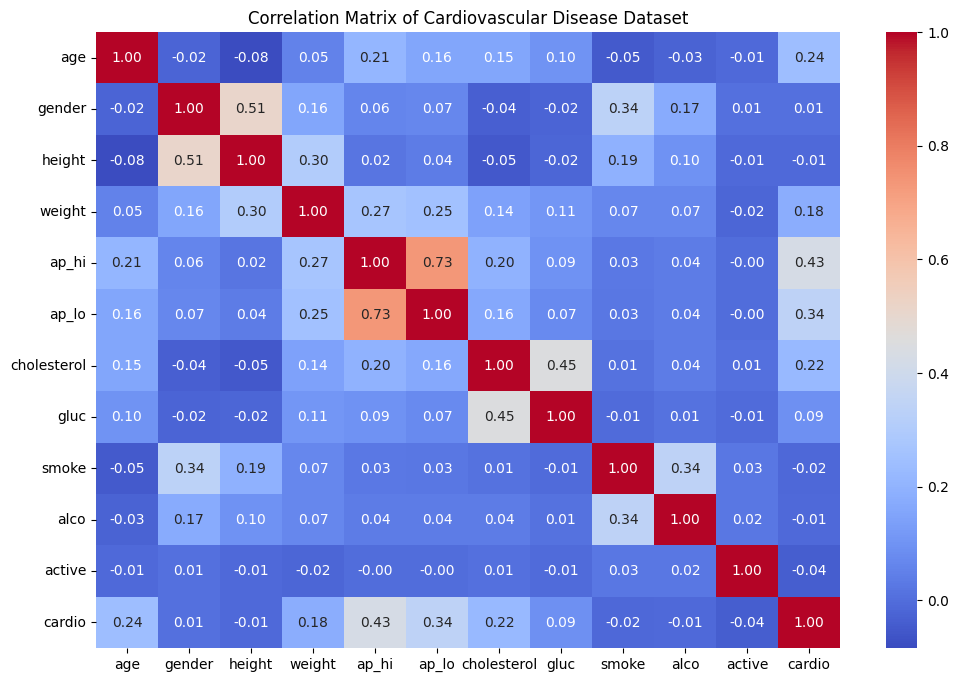

In [6]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Cardiovascular Disease Dataset')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (54905, 11)
Testing data: (13727, 11)


In [8]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("SVM Accuracy:", svm_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

SVM Accuracy: 0.7365775478983027
KNN Accuracy: 0.695709186275224
Decision Tree Accuracy: 0.6359000509943906
Logistic Regression Accuracy: 0.7287098419173891
Random Forest Accuracy: 0.7113717491075982


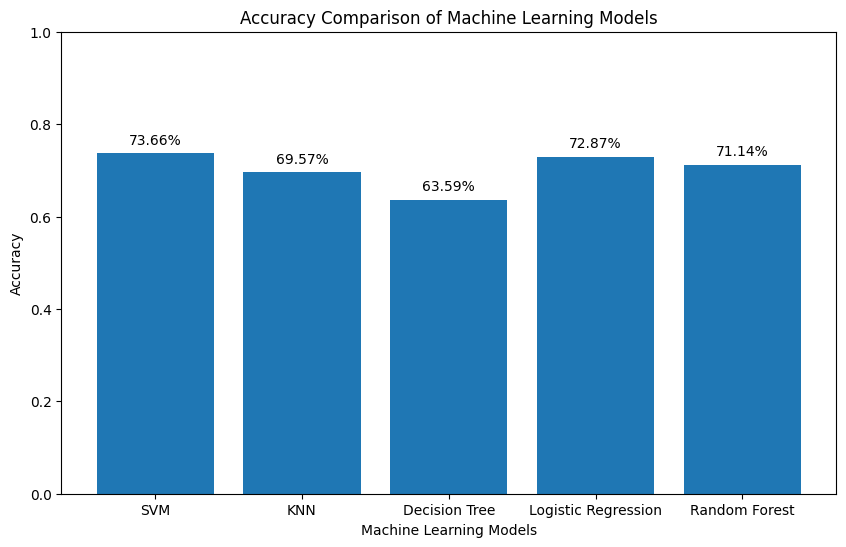

In [9]:
models = ['SVM', 'KNN', 'Decision Tree', 'Logistic Regression', 'Random Forest']
accuracies = [
    svm_accuracy,
    knn_accuracy,
    dt_accuracy,
    lr_accuracy,
    rf_accuracy
]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)

plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for i in range(len(models)):
    plt.text(i, accuracies[i] + 0.02, f'{accuracies[i] * 100:.2f}%', ha='center')

plt.show()

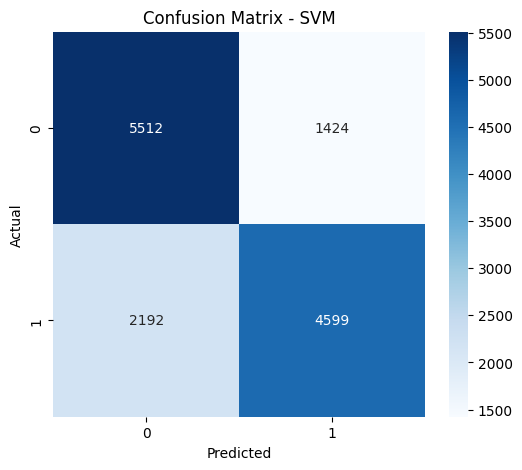

Classification Report - SVM
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      6936
           1       0.76      0.68      0.72      6791

    accuracy                           0.74     13727
   macro avg       0.74      0.74      0.74     13727
weighted avg       0.74      0.74      0.74     13727



In [10]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report - SVM")
print(classification_report(y_test, svm_pred))

In [12]:
final_model = svm_model

print("Final Model: Support Vector Machine (SVM)")
print("Accuracy:", svm_accuracy * 100, "%")

new_patient = pd.DataFrame([[
    50, 2, 168, 62, 120, 80, 1, 1, 0, 0, 1
]], columns=X.columns)

new_patient_scaled = scaler.transform(new_patient)

prediction = final_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Heart Disease Detection: Cardiovascular Disease Detected")
else:
    print("Heart Disease Detection: No Cardiovascular Disease Detected")

Final Model: Support Vector Machine (SVM)
Accuracy: 73.65775478983026 %
Heart Disease Detection: No Cardiovascular Disease Detected
